Accuracy: 0.9743589743589743

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision : 0.96
Recall    : 1.0
F1 Score  : 0.98


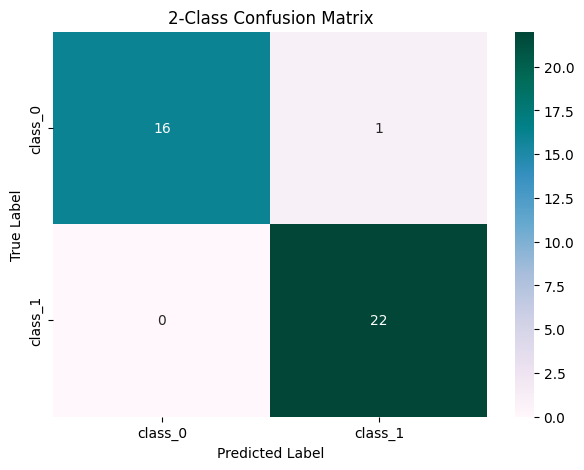

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

wine = load_wine()


data = pd.DataFrame(wine.data, columns=wine.feature_names)
data["Target"] = wine.target


data = data[data["Target"] != 2]


X = data.drop("Target", axis=1)
y = data["Target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)


model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names[:2]
))


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1 Score  :", round(f1, 2))


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    xticklabels=wine.target_names[:2],
    yticklabels=wine.target_names[:2]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("2-Class Confusion Matrix")

plt.show()